In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent, professional style across all charts
sns.set_style("whitegrid")
sns.set_palette("viridis")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

# Load the cleaned dataset from Task 2
df = pd.read_csv("data/books_clean.csv")

print("Shape:", df.shape)
print(df.head())

Shape: (1000, 3)
                                   title  price  rating
0                   A Light in the Attic  51.77       3
1                     Tipping the Velvet  53.74       1
2                             Soumission  50.10       1
3                          Sharp Objects  47.82       4
4  Sapiens: A Brief History of Humankind  54.23       5


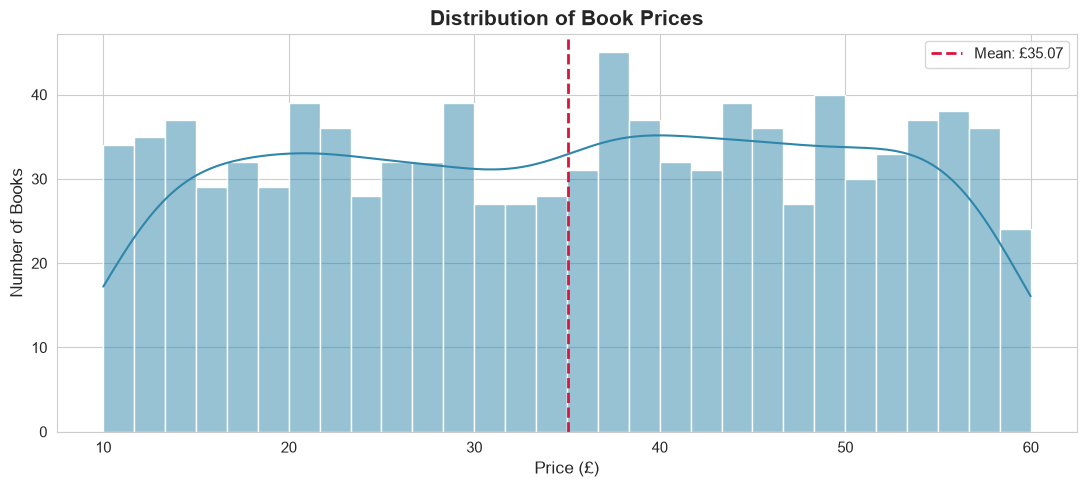

In [2]:
fig, ax = plt.subplots(figsize=(11, 5))

sns.histplot(data=df, x="price", bins=30, kde=True,
             color="#2E86AB", edgecolor="white", ax=ax)

# Add mean line
mean_price = df["price"].mean()
ax.axvline(mean_price, color="crimson", linestyle="--", linewidth=2,
           label=f"Mean: £{mean_price:.2f}")

ax.set_title("Distribution of Book Prices", fontsize=15, fontweight="bold")
ax.set_xlabel("Price (£)", fontsize=12)
ax.set_ylabel("Number of Books", fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig("data/chart1_price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10976\3259049327.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=avg_price, x="rating", y="price",


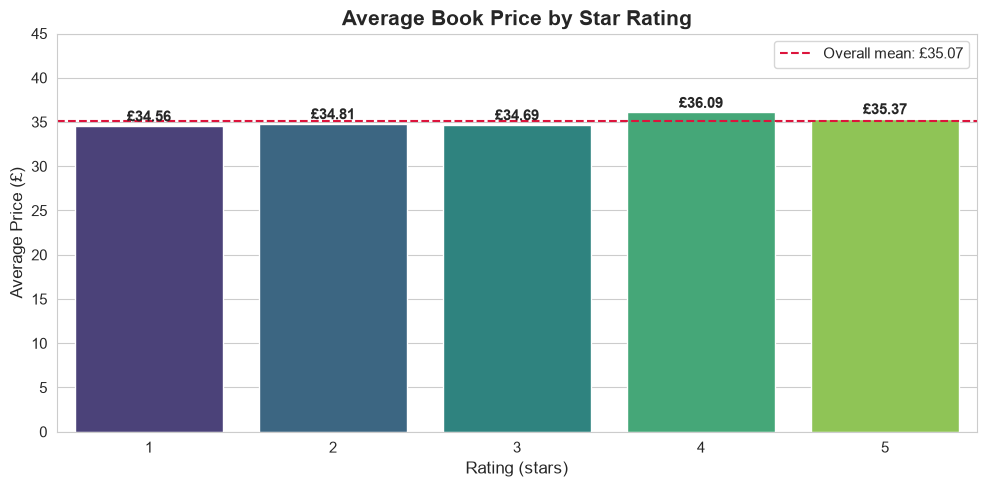

In [3]:
# Compute average price per rating
avg_price = df.groupby("rating")["price"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

bars = sns.barplot(data=avg_price, x="rating", y="price",
                   palette="viridis", ax=ax)

# Annotate each bar with the value
for i, row in avg_price.iterrows():
    ax.text(i, row["price"] + 0.5, f"£{row['price']:.2f}",
            ha="center", fontsize=11, fontweight="bold")

# Add overall mean reference line
overall_mean = df["price"].mean()
ax.axhline(overall_mean, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Overall mean: £{overall_mean:.2f}")

ax.set_title("Average Book Price by Star Rating", fontsize=15, fontweight="bold")
ax.set_xlabel("Rating (stars)", fontsize=12)
ax.set_ylabel("Average Price (£)", fontsize=12)
ax.set_ylim(0, 45)
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig("data/chart2_rating_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10976\645849309.py:26: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_10976\645849309.py:27: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig("data/chart3_rating_distribution.png", dpi=150, bbox_inches="tight")
c:\Users\Admin\Desktop\My final year project\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


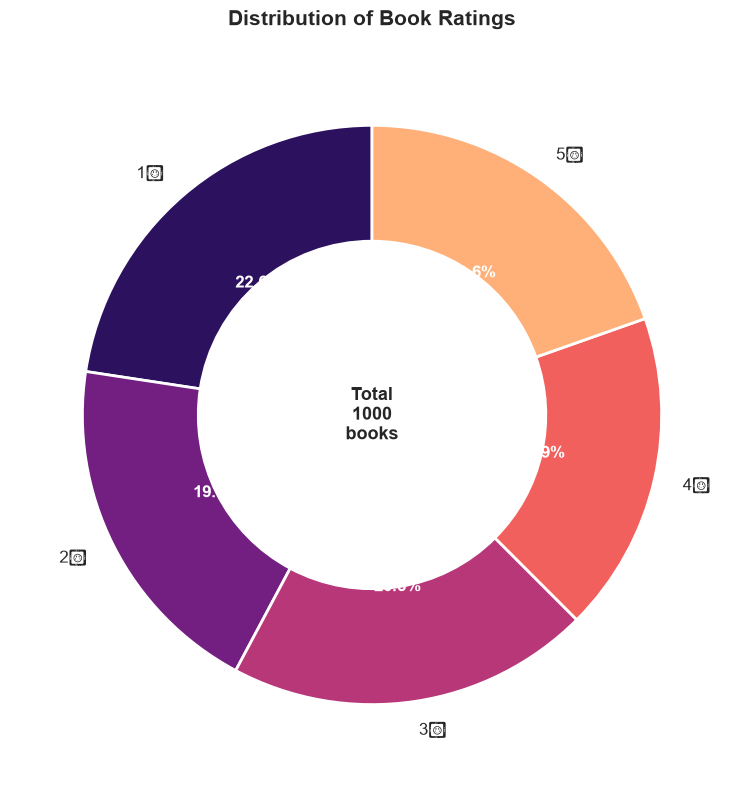

In [4]:
rating_counts = df["rating"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 8))

colors = sns.color_palette("magma", len(rating_counts))
wedges, texts, autotexts = ax.pie(
    rating_counts,
    labels=[f"{r}★" for r in rating_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"width": 0.4, "edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 12}
)

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

# Center annotation
ax.text(0, 0, f"Total\n{len(df)}\nbooks",
        ha="center", va="center", fontsize=13, fontweight="bold")

ax.set_title("Distribution of Book Ratings", fontsize=15, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("data/chart3_rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_10976\3777956499.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10["price"], y=labels, palette="rocket", ax=ax)


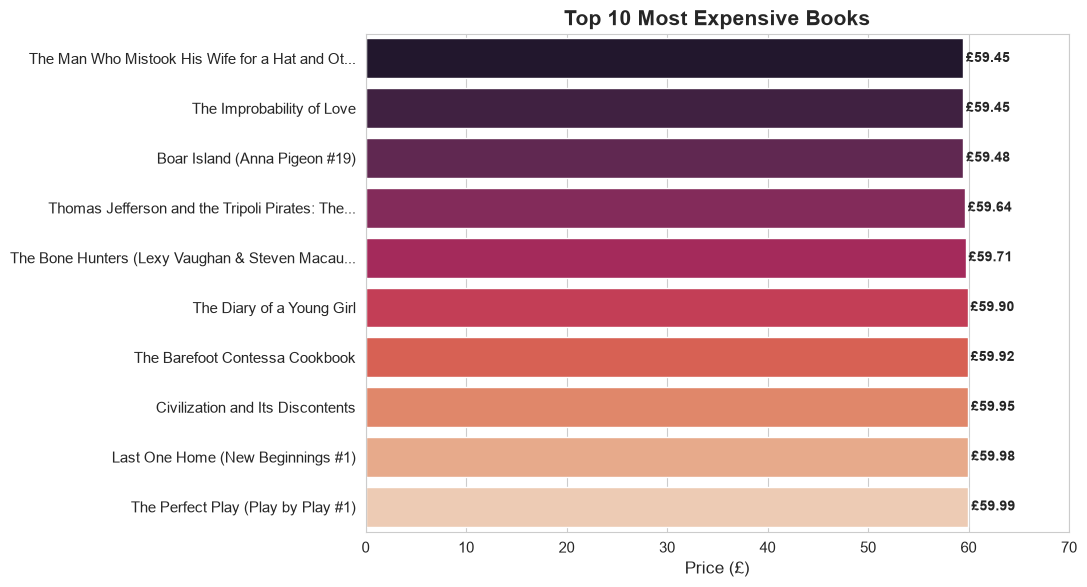

In [5]:
top10 = df.nlargest(10, "price").sort_values("price")

fig, ax = plt.subplots(figsize=(11, 6))

# Truncate long titles for readability
labels = [t[:45] + "..." if len(t) > 45 else t for t in top10["title"]]

sns.barplot(x=top10["price"], y=labels, palette="rocket", ax=ax)

# Annotate prices
for i, price in enumerate(top10["price"]):
    ax.text(price + 0.3, i, f"£{price:.2f}",
            va="center", fontsize=10, fontweight="bold")

ax.set_title("Top 10 Most Expensive Books", fontsize=15, fontweight="bold")
ax.set_xlabel("Price (£)", fontsize=12)
ax.set_ylabel("")
ax.set_xlim(0, 70)

plt.tight_layout()
plt.savefig("data/chart4_top10_expensive.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10976\1810495471.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="rating", y="price",


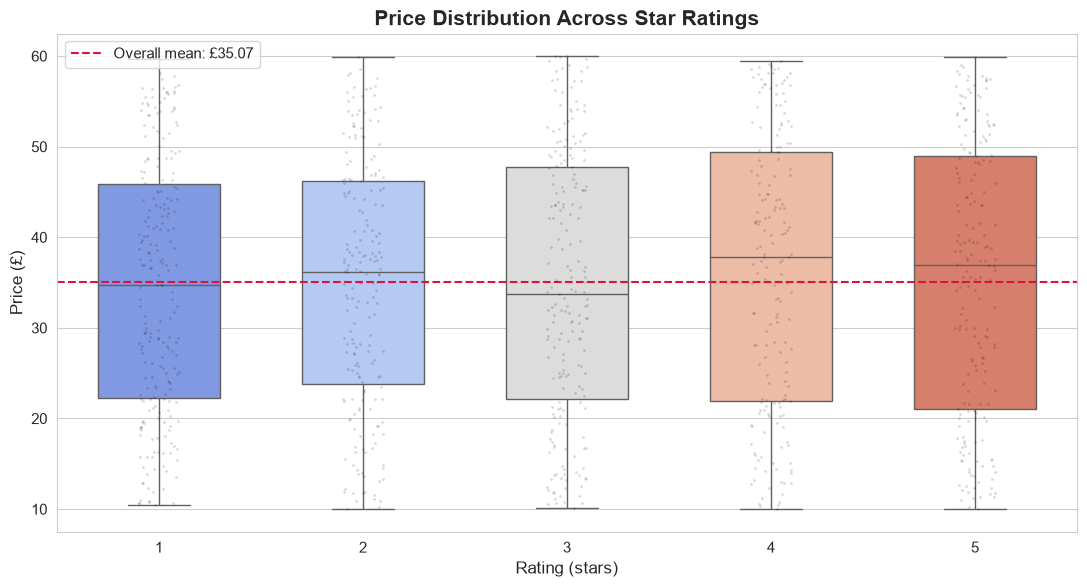

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.boxplot(data=df, x="rating", y="price",
            palette="coolwarm", width=0.6, ax=ax)

# Overlay individual data points (jittered) for depth
sns.stripplot(data=df, x="rating", y="price",
              color="black", alpha=0.15, size=2, ax=ax)

# Reference line at overall mean
ax.axhline(df["price"].mean(), color="crimson",
           linestyle="--", linewidth=1.5,
           label=f"Overall mean: £{df['price'].mean():.2f}")

ax.set_title("Price Distribution Across Star Ratings", fontsize=15, fontweight="bold")
ax.set_xlabel("Rating (stars)", fontsize=12)
ax.set_ylabel("Price (£)", fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig("data/chart5_price_vs_rating_box.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10976\1555890285.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price, x="rating", y="price",
C:\Users\Admin\AppData\Local\Temp\ipykernel_10976\1555890285.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="rating", palette="magma", ax=axes[1, 0])
C:\Users\Admin\AppData\Local\Temp\ipykernel_10976\1555890285.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="rating", y="price",


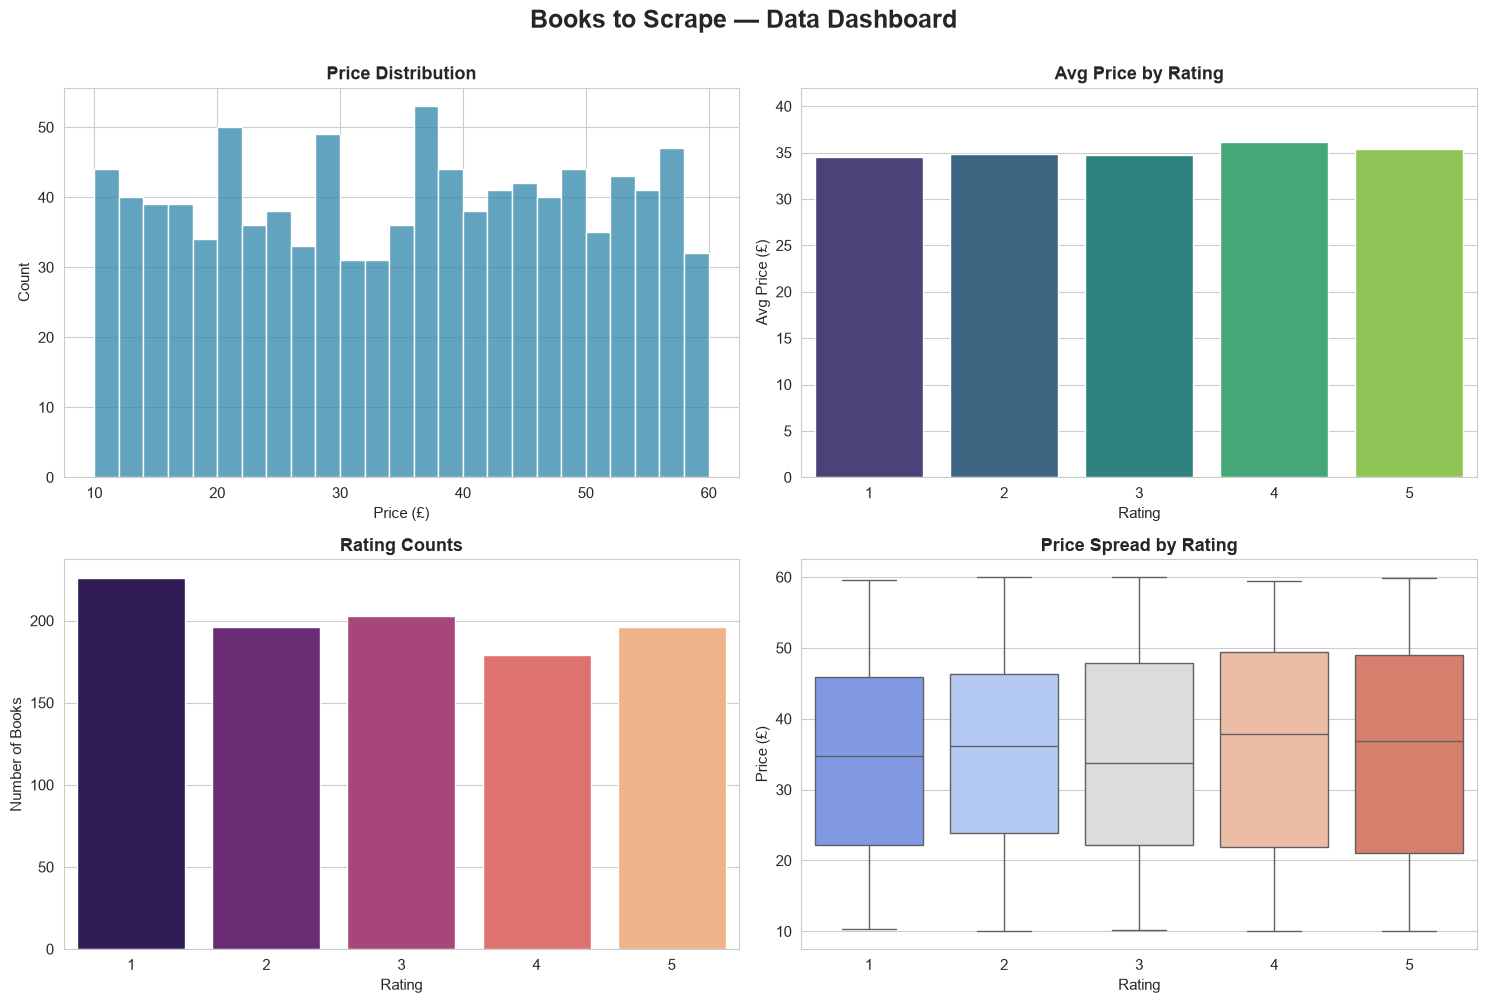

✅ Dashboard saved to data/dashboard.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Books to Scrape — Data Dashboard",
             fontsize=18, fontweight="bold", y=1.00)

# 1. Price histogram
sns.histplot(data=df, x="price", bins=25, color="#2E86AB",
             edgecolor="white", ax=axes[0, 0])
axes[0, 0].set_title("Price Distribution", fontweight="bold")
axes[0, 0].set_xlabel("Price (£)")
axes[0, 0].set_ylabel("Count")

# 2. Avg price per rating
sns.barplot(data=avg_price, x="rating", y="price",
            palette="viridis", ax=axes[0, 1])
axes[0, 1].set_title("Avg Price by Rating", fontweight="bold")
axes[0, 1].set_xlabel("Rating")
axes[0, 1].set_ylabel("Avg Price (£)")
axes[0, 1].set_ylim(0, 42)

# 3. Rating counts
sns.countplot(data=df, x="rating", palette="magma", ax=axes[1, 0])
axes[1, 0].set_title("Rating Counts", fontweight="bold")
axes[1, 0].set_xlabel("Rating")
axes[1, 0].set_ylabel("Number of Books")

# 4. Boxplot
sns.boxplot(data=df, x="rating", y="price",
            palette="coolwarm", ax=axes[1, 1])
axes[1, 1].set_title("Price Spread by Rating", fontweight="bold")
axes[1, 1].set_xlabel("Rating")
axes[1, 1].set_ylabel("Price (£)")

plt.tight_layout()
plt.savefig("data/dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Dashboard saved to data/dashboard.png")

## 📈 Visualization Summary

### What the charts reveal

1. **Price Distribution** — Books span £10–£60 with a roughly uniform spread, mean ≈ £35. No dominant pricing tier.

2. **Rating vs Average Price** — Average price stays flat (~£34–£36) across all star ratings. This visually confirms zero correlation.

3. **Rating Distribution** — Each rating tier holds ~20% of the catalog. The site is intentionally balanced.

4. **Top 10 Most Expensive** — Highest-priced titles cluster around £55–£60. Titles are long and varied.

5. **Price Spread by Rating** — Box plots overlap heavily — price dispersion is similar regardless of rating.

### Data Story

> "On books.toscrape.com, price and rating operate independently. A reader cannot assume that higher-rated books cost more — the data shows no relationship. The site offers a balanced catalog across both price ranges and quality tiers, making it a fair sandbox for price-rating analysis."

### Tools Used
- Matplotlib & Seaborn for all charts
- Cleaned dataset from Task 2 (`books_clean.csv`)